In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from darts import TimeSeries
from darts.models import TransformerModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse, r2_score


/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [3]:
# --- 2. Clock-Anchored Feature Engineering ---
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

FEATURE_COLS = ["pm2_5 (μg/m³)", "hour_sin", "hour_cos"]
TARGET_COL = "pm2_5 (μg/m³)"

df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

# --- 3. Darts TimeSeries Extraction ---
all_features_series = TimeSeries.from_dataframe(df, value_cols=FEATURE_COLS)
target_series = TimeSeries.from_dataframe(df, value_cols=[TARGET_COL])
covariates_series = TimeSeries.from_dataframe(df, value_cols=["hour_sin", "hour_cos"])

# --- 4. Chronological Splitting ---
SPLIT_DATE = pd.Timestamp("2025-01-01 00:00:00")

train_target, val_target = target_series.split_before(SPLIT_DATE)
train_cov, val_cov = covariates_series.split_before(SPLIT_DATE)

In [4]:
# --- 5. Data Normalization (Scikit-Learn Wrapper) ---
target_scaler = Scaler(MinMaxScaler())
cov_scaler = Scaler(MinMaxScaler())

train_target_scaled = target_scaler.fit_transform(train_target)
val_target_scaled = target_scaler.transform(val_target)

train_cov_scaled = cov_scaler.fit_transform(train_cov)
val_cov_scaled = cov_scaler.transform(val_cov)

In [5]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [6]:
INPUT_WINDOW = 24 * 3
OUTPUT_WINDOW = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")

model = TransformerModel(
    input_chunk_length=INPUT_WINDOW,
    output_chunk_length=OUTPUT_WINDOW,
    d_model=64,
    nhead=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=128,
    dropout=0.3,
    activation="relu",
    batch_size=64,
    n_epochs=60,
    optimizer_kwargs={"lr": 1e-3, "weight_decay": 1e-5},
    pl_trainer_kwargs={"accelerator": DEVICE, "devices": 1, "callbacks": [loss_tracker]},
)

model.fit(series=train_target_scaled, past_covariates=train_cov_scaled, val_series=val_target_scaled, val_past_covariates=val_cov_scaled)

/data/ll2531/venv/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)
/data/ll2531/venv/lib/python3.10/site-packages/torch/random.py:187: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you 

Epoch 59: 100%|██████████| 1232/1232 [00:23<00:00, 52.58it/s, train_loss=0.00671, val_loss=0.00252]

`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 59: 100%|██████████| 1232/1232 [00:23<00:00, 52.58it/s, train_loss=0.00671, val_loss=0.00252]


TransformerModel(output_chunk_shift=0, d_model=64, nhead=8, num_encoder_layers=3, num_decoder_layers=3, dim_feedforward=128, dropout=0.3, activation=relu, norm_type=None, custom_encoder=None, custom_decoder=None, input_chunk_length=72, output_chunk_length=24, batch_size=64, n_epochs=60, optimizer_kwargs={'lr': 0.001, 'weight_decay': 1e-05}, pl_trainer_kwargs={'accelerator': 'cuda', 'devices': 1, 'callbacks': [<__main__.SimpleLossTracker object at 0x7f6adc6eb430>]})

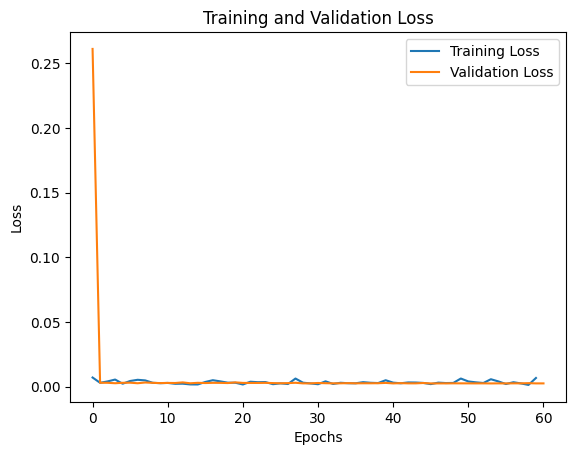

In [7]:
plt.plot(loss_tracker.train_losses, label='Training Loss')
plt.plot(loss_tracker.val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2

print("Generating rolling predictions (1-hour stride)...")
scaled_forecasts = model.historical_forecasts(
    series=val_target_scaled,
    past_covariates=val_cov_scaled,
    start=INPUT_WINDOW,
    forecast_horizon=OUTPUT_WINDOW,
    stride=1,
    retrain=False,
    last_points_only=False
)

true_forecasts = [target_scaler.inverse_transform(f) for f in scaled_forecasts]
true_targets = [val_target.slice_intersect(f) for f in true_forecasts]

all_pred_values = np.concatenate([f.univariate_values() for f in true_forecasts])
all_true_values = np.concatenate([t.univariate_values() for t in true_targets])

# --- 4. Global Metrics Calculation ---
global_mae = mean_absolute_error(all_true_values, all_pred_values)
global_rmse = np.sqrt(mean_squared_error(all_true_values, all_pred_values))
global_r2 = sklearn_r2(all_true_values, all_pred_values)

baseline_mean = np.mean(all_true_values)
mae_percentage = (global_mae / baseline_mean)
rmse_percentage = (global_rmse / baseline_mean)

print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")


Generating rolling predictions (1-hour stride)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Global R² Score     : 0.5744
Global MAE          : 2.3926 μg/m³
Global RMSE         : 3.7587 μg/m³
MAE% (Normalized)   : 0.32
RMSE% (Normalized)  : 0.50


In [9]:
import plotly.graph_objects as go

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

fig_darts = go.Figure()
buttons_darts = []

for idx, sample_idx in enumerate(sample_indices):
    # FIXED: Extract the single TimeSeries chunk directly from the list instead of sub-slicing
    target_chunk = true_targets[sample_idx]
    forecast_chunk = true_forecasts[sample_idx]
    
    # Extract univariate numpy arrays out of the single TimeSeries object
    true_actual_darts = target_chunk.univariate_values()
    true_pred_darts = forecast_chunk.univariate_values()
    
    # Extract the timestamps from the chunk
    window_timestamps_darts = target_chunk.time_index
    time_labels_darts = [str(t).split()[1][:5] for t in window_timestamps_darts]
    date_str_darts = str(window_timestamps_darts[0]).split()[0]
    
    fig_darts.add_trace(go.Scatter(
        x=time_labels_darts, y=true_actual_darts, mode='lines+markers',
        name=f'Actual PM2.5 ({date_str_darts})', line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    fig_darts.add_trace(go.Scatter(
        x=time_labels_darts, y=true_pred_darts, mode='lines+markers',
        name=f'Darts Transformer Forecast ({date_str_darts})', line=dict(color='darkorange', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask_darts = [False] * (num_samples * 2)
    visibility_mask_darts[idx * 2] = True
    visibility_mask_darts[idx * 2 + 1] = True
    
    buttons_darts.append(dict(
        label=f"Horizon: {date_str_darts}", method="update",
        args=[{"visible": visibility_mask_darts}, {"title": f"<b>Darts Transformer Performance Horizon: {date_str_darts}</b>"}]
    ))

# FIXED: Extract the date string safely from the first time series element in the list
initial_date_darts = str(true_targets[0].time_index[0]).split()[0]

fig_darts.update_layout(
    title=dict(text=f'<b>Darts Transformer Performance Horizon: {initial_date_darts}</b>', x=0.5, font=dict(size=16)),
    updatemenus=[dict(buttons=buttons_darts, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.0, xanchor="left", y=1.15, yanchor="top")],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white', hovermode='x unified', height=550, width=900,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_darts.show()